In [1]:
# ============================================================
# MINITIENDA - REGISTRO Y ANÁLISIS DE VENTAS
# UIDE - Programación
# Alumno: Carlos Daniel Vasquez Navas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------- CATÁLOGO, PRECIOS Y STOCK ----------
catalogo = (
    (1, "Aceite 10W40"),
    (2, "Filtro de aceite"),
    (3, "Bujía"),
    (4, "Refrigerante"),
    (5, "Limpiador de frenos"),
    (6, "Filtro de aire")       # Reto A
)

precios = {
    1: 8.50, 2: 6.00, 3: 4.50,
    4: 7.00, 5: 5.50, 6: 9.00
}

stock = {
    1: 30, 2: 25, 3: 40,
    4: 20, 5: 25, 6: 20
}

ventas = []
ids_ventas = []
contador = 1


# ---------- FUNCIONES ----------
def buscar_producto(producto_id):
    for producto in catalogo:
        if producto[0] == producto_id:
            return producto[1]
    return None


def registrar_log(mensaje):
    with open("log.txt", "a", encoding="utf-8") as archivo:
        archivo.write(mensaje + "\n")


def registrar_venta(producto_id, unidades):
    global contador

    nombre = buscar_producto(producto_id)

    if nombre is None:
        registrar_log(f"Intento fallido: producto {producto_id} no existe")
        print("ERROR: producto no existe.")
        return

    if unidades <= 0:
        print("ERROR: cantidad inválida.")
        return

    if unidades > stock[producto_id]:
        print("ERROR: stock insuficiente.")
        return

    precio = precios[producto_id]
    subtotal = precio * unidades

    # Reto C: descuento del 5%
    if unidades >= 10:
        descuento = subtotal * 0.05
    else:
        descuento = 0

    total = subtotal - descuento
    stock[producto_id] -= unidades

    ventas.append({
        "id_venta": contador,
        "producto_id": producto_id,
        "producto": nombre,
        "unidades": unidades,
        "precio": precio,
        "descuento": descuento,
        "total": total
    })

    ids_ventas.append(contador)
    contador += 1

    print(f"Venta registrada: {nombre} | Total: ${total:.2f}")


def mostrar_catalogo():
    print("\n===== CATÁLOGO =====")
    for id_producto, nombre in catalogo:
        print(f"{id_producto} - {nombre} | "
              f"${precios[id_producto]:.2f} | "
              f"Stock: {stock[id_producto]}")


def analizar_ventas():
    if not ventas:
        print("No hay ventas.")
        return

    df = pd.DataFrame(ventas)

    # Pandas
    ingresos = df.groupby("producto")["total"].sum()

    # NumPy
    datos = np.array(df["total"])
    print("\n===== MÉTRICAS =====")
    print(f"Total: ${np.sum(datos):.2f}")
    print(f"Promedio: ${np.mean(datos):.2f}")
    print(f"Desviación estándar: ${np.std(datos):.2f}")

    print("\n===== VENTAS POR PRODUCTO =====")
    print(ingresos)

    # Matplotlib
    ingresos.plot(kind="bar")
    plt.title("Ingresos por producto")
    plt.xlabel("Producto")
    plt.ylabel("Ingresos ($)")
    plt.tight_layout()
    plt.show()


def guardar_csv():
    if ventas:
        pd.DataFrame(ventas).to_csv("ventas.csv", index=False)
        print("Ventas guardadas en ventas.csv")
    else:
        print("No hay ventas.")


def cargar_csv():
    if os.path.exists("ventas.csv"):
        df = pd.read_csv("ventas.csv")
        print(df)
    else:
        print("ERROR: ventas.csv no existe.")


# ---------- MENÚ ----------
def menu():
    while True:
        print("\n===== MINITIENDA =====")
        print("1. Mostrar catálogo")
        print("2. Registrar venta")
        print("3. Ver ventas")
        print("4. Analizar ventas")
        print("5. Guardar CSV")
        print("6. Exportar gráfico PNG")
        print("7. Cargar CSV")
        print("0. Salir")

        opcion = input("Seleccione una opción: ")

        if opcion == "1":
            mostrar_catalogo()

        elif opcion == "2":
            try:
                producto = int(input("ID del producto: "))
                cantidad = int(input("Cantidad: "))
            except ValueError:
                print("ERROR: ingrese números.")
            else:
                registrar_venta(producto, cantidad)
            finally:
                print("Proceso terminado.")

        elif opcion == "3":
            if ventas:
                print(pd.DataFrame(ventas))
            else:
                print("No hay ventas.")

        elif opcion == "4":
            analizar_ventas()

        elif opcion == "5":
            guardar_csv()

        elif opcion == "6":
            if ventas:
                df = pd.DataFrame(ventas)
                ingresos = df.groupby("producto")["total"].sum()
                ingresos.plot(kind="bar")
                plt.title("Ingresos por producto")
                plt.ylabel("Ingresos ($)")
                plt.tight_layout()
                plt.savefig("ingresos.png")
                plt.show()
                print("Gráfico guardado como ingresos.png")
            else:
                print("No hay ventas.")

        elif opcion == "7":
            cargar_csv()

        elif opcion == "0":
            print("Programa finalizado.")
            break

        else:
            print("Opción inválida.")
            continue


print("MiniTienda cargada correctamente.")
mostrar_catalogo()

MiniTienda cargada correctamente.

===== CATÁLOGO =====
1 - Aceite 10W40 | $8.50 | Stock: 30
2 - Filtro de aceite | $6.00 | Stock: 25
3 - Bujía | $4.50 | Stock: 40
4 - Refrigerante | $7.00 | Stock: 20
5 - Limpiador de frenos | $5.50 | Stock: 25
6 - Filtro de aire | $9.00 | Stock: 20


Venta registrada: Aceite 10W40 | Total: $17.00
Venta registrada: Filtro de aceite | Total: $18.00
Venta registrada: Bujía | Total: $22.50
Venta registrada: Refrigerante | Total: $14.00
Venta registrada: Limpiador de frenos | Total: $22.00
Venta registrada: Filtro de aire | Total: $27.00
Venta registrada: Aceite 10W40 | Total: $80.75
Venta registrada: Filtro de aceite | Total: $12.00
Venta registrada: Bujía | Total: $18.00
Venta registrada: Refrigerante | Total: $21.00
Ventas guardadas en ventas.csv

===== DATAFRAME DE VENTAS =====


,id_venta,producto_id,producto,unidades,precio,descuento,total
0,1,1,Aceite 10W40,2,8.5,0.00,17.00
1,2,2,Filtro de aceite,3,6.0,0.00,18.00
2,3,3,Bujía,5,4.5,0.00,22.50
3,4,4,Refrigerante,2,7.0,0.00,14.00
4,5,5,Limpiador de frenos,4,5.5,0.00,22.00
5,6,6,Filtro de aire,3,9.0,0.00,27.00
6,7,1,Aceite 10W40,10,8.5,4.25,80.75
7,8,2,Filtro de aceite,2,6.0,0.00,12.00
8,9,3,Bujía,4,4.5,0.00,18.00
9,10,4,Refrigerante,3,7.0,0.00,21.00



===== MÉTRICAS NUMPY =====
Suma: $252.25
Promedio: $25.23
Desviación estándar: $18.96

===== INGRESOS POR PRODUCTO =====


,total
producto,
Aceite 10W40,97.75
Bujía,40.50
Filtro de aceite,30.00
Filtro de aire,27.00
Limpiador de frenos,22.00
Refrigerante,35.00


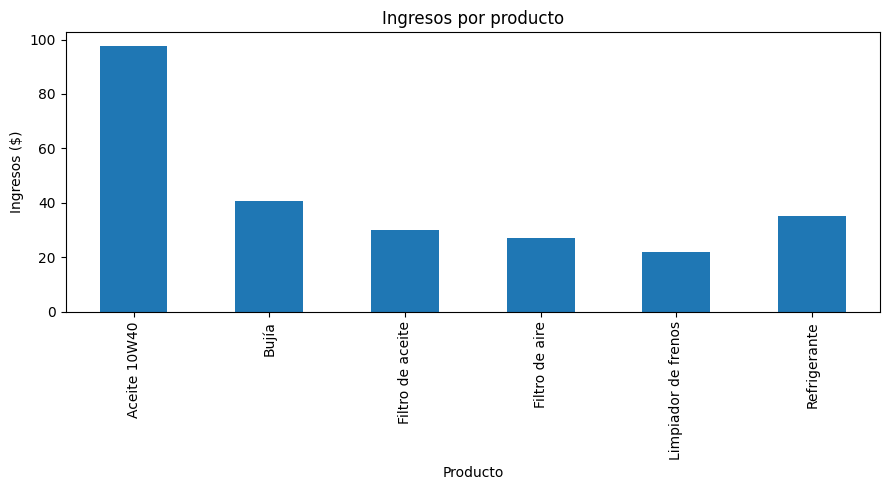

✓ ventas.csv creado
✓ ingresos.png creado
✓ log.txt disponible

===== PRUEBA DE PRODUCTO INEXISTENTE =====
ERROR: producto no existe.


In [2]:
# ============================================================
# PRUEBAS Y GENERACIÓN DE ARCHIVOS
# ============================================================

# Registrar 10 ventas
ventas_prueba = [
    (1, 2),
    (2, 3),
    (3, 5),
    (4, 2),
    (5, 4),
    (6, 3),
    (1, 10),   # activa descuento del 5%
    (2, 2),
    (3, 4),
    (4, 3)
]

for producto, cantidad in ventas_prueba:
    registrar_venta(producto, cantidad)

# Guardar CSV
guardar_csv()

# Mostrar DataFrame
df = pd.DataFrame(ventas)
print("\n===== DATAFRAME DE VENTAS =====")
display(df)

# Métricas con NumPy
datos = np.array(df["total"])

print("\n===== MÉTRICAS NUMPY =====")
print(f"Suma: ${np.sum(datos):.2f}")
print(f"Promedio: ${np.mean(datos):.2f}")
print(f"Desviación estándar: ${np.std(datos):.2f}")

# Ingresos por producto con Pandas
ingresos = df.groupby("producto")["total"].sum()

print("\n===== INGRESOS POR PRODUCTO =====")
display(ingresos)

# Gráfico
plt.figure(figsize=(9,5))
ingresos.plot(kind="bar")
plt.title("Ingresos por producto")
plt.xlabel("Producto")
plt.ylabel("Ingresos ($)")
plt.tight_layout()
plt.savefig("ingresos.png")
plt.show()

print("✓ ventas.csv creado")
print("✓ ingresos.png creado")
print("✓ log.txt disponible")

# Prueba del Reto D
print("\n===== PRUEBA DE PRODUCTO INEXISTENTE =====")
registrar_venta(99, 2)


===== MINITIENDA =====
1. Mostrar catálogo
2. Registrar venta
3. Ver ventas
4. Analizar ventas
5. Guardar CSV
6. Exportar gráfico PNG
7. Cargar CSV
0. Salir
Seleccione una opción: 1

===== CATÁLOGO =====
1 - Aceite 10W40 | $8.50 | Stock: 18
2 - Filtro de aceite | $6.00 | Stock: 20
3 - Bujía | $4.50 | Stock: 31
4 - Refrigerante | $7.00 | Stock: 15
5 - Limpiador de frenos | $5.50 | Stock: 21
6 - Filtro de aire | $9.00 | Stock: 17

===== MINITIENDA =====
1. Mostrar catálogo
2. Registrar venta
3. Ver ventas
4. Analizar ventas
5. Guardar CSV
6. Exportar gráfico PNG
7. Cargar CSV
0. Salir
Seleccione una opción: 3
   id_venta  producto_id             producto  unidades  precio  descuento  \
0         1            1         Aceite 10W40         2     8.5       0.00   
1         2            2     Filtro de aceite         3     6.0       0.00   
2         3            3                Bujía         5     4.5       0.00   
3         4            4         Refrigerante         2     7.0       0.

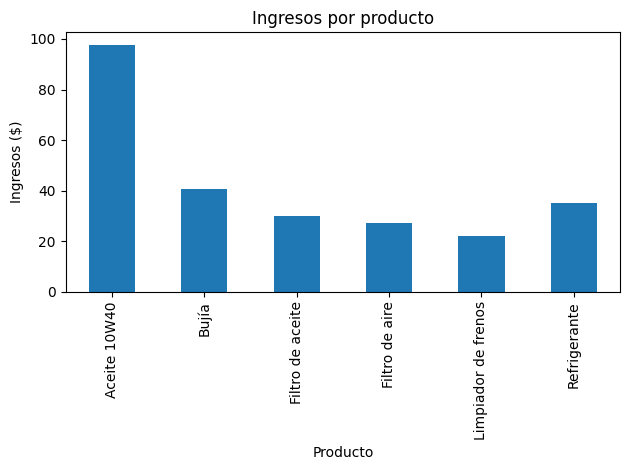


===== MINITIENDA =====
1. Mostrar catálogo
2. Registrar venta
3. Ver ventas
4. Analizar ventas
5. Guardar CSV
6. Exportar gráfico PNG
7. Cargar CSV
0. Salir
Seleccione una opción: 5
Ventas guardadas en ventas.csv

===== MINITIENDA =====
1. Mostrar catálogo
2. Registrar venta
3. Ver ventas
4. Analizar ventas
5. Guardar CSV
6. Exportar gráfico PNG
7. Cargar CSV
0. Salir
Seleccione una opción: 6


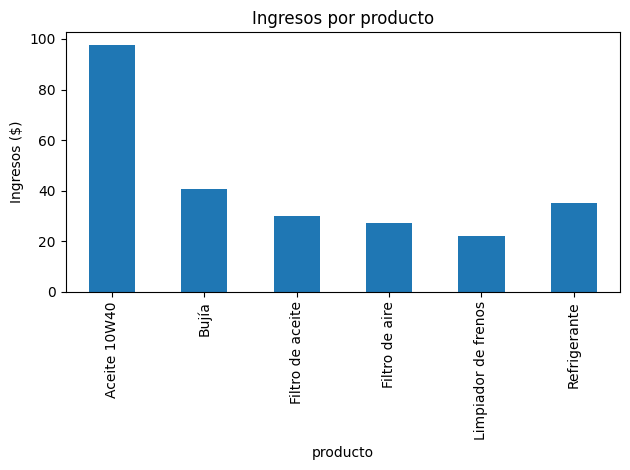

Gráfico guardado como ingresos.png

===== MINITIENDA =====
1. Mostrar catálogo
2. Registrar venta
3. Ver ventas
4. Analizar ventas
5. Guardar CSV
6. Exportar gráfico PNG
7. Cargar CSV
0. Salir
Seleccione una opción: 7
   id_venta  producto_id             producto  unidades  precio  descuento  \
0         1            1         Aceite 10W40         2     8.5       0.00   
1         2            2     Filtro de aceite         3     6.0       0.00   
2         3            3                Bujía         5     4.5       0.00   
3         4            4         Refrigerante         2     7.0       0.00   
4         5            5  Limpiador de frenos         4     5.5       0.00   
5         6            6       Filtro de aire         3     9.0       0.00   
6         7            1         Aceite 10W40        10     8.5       4.25   
7         8            2     Filtro de aceite         2     6.0       0.00   
8         9            3                Bujía         4     4.5       0.00   
9 

In [4]:
menu()